2) Create a data frame that allows searching for all synonyms of a given drug based on its DrugBank ID. Write a function that, for a given DrugBank ID, creates and visualizes a synonym graph using the NetworkX library. Ensure the generated visualization is clear and readable.

In [1]:
!pip install networkx

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import xml.etree.ElementTree as ET
import pandas as pd

# Define the file path and namespaces
file_path = 'drugbank_partial.xml'
namespaces = {'drugbank': 'http://www.drugbank.ca'}

data = []
depth = 0

# Parse the XML file and extract relevant information
for event, elem in ET.iterparse(file_path, events=('start', 'end')):
    if event == 'start':
        depth += 1
    elif event == 'end':
        depth -= 1

    # Process each drug element when the end tag is encountered
    if elem.tag == f"{{{namespaces['drugbank']}}}drug" and event == 'end' and depth == 1:
        drug_data = {}

        # Extract the primary drugbank-id
        drugbank_id_elem = elem.find('drugbank:drugbank-id[@primary="true"]', namespaces)
        if drugbank_id_elem is not None:
            drug_data['drugbank-id'] = drugbank_id_elem.text

        # Extract synonyms
        synonyms_elem = elem.find('drugbank:synonyms', namespaces)
        if synonyms_elem is not None:
            synonyms = [synonym.text for synonym in synonyms_elem.findall('drugbank:synonym', namespaces)]
            drug_data['synonyms'] = synonyms

        data.append(drug_data)
        elem.clear()

# Create a DataFrame from the extracted data
df = pd.DataFrame(data)
df

,drugbank-id,synonyms
0,DB00001,"[[Leu1, Thr2]-63-desulfohirudin, Desulfatohiru..."
1,DB00002,"[Cetuximab, Cétuximab, Cetuximabum]"
2,DB00003,[Deoxyribonuclease (human clone 18-1 protein m...
3,DB00004,"[Denileukin, Denileukin diftitox, Interleukin-..."
4,DB00005,"[Etanercept, etanercept-szzs, etanercept-ykro,..."
...,...,...
95,DB00104,"[Octreotida, Octreotide, Octreotidum, Octrotide]"
96,DB00105,"[Interferon alfa-2b, Interferon alfa-2b (recom..."
97,DB00106,[Abarelix]
98,DB00107,"[Oxitocina, Oxytocin]"


In [2]:
import textwrap
import networkx as nx
import matplotlib.pyplot as plt


# Function to draw a graph of synonyms for a given DrugBank ID
def draw_synonyms_graph(drugbank_id):
    drug_synonyms = df[df['drugbank-id'] == drugbank_id]['synonyms'].values[0]
    G = nx.Graph()
    G.add_node(drugbank_id)
    for synonym in drug_synonyms:
        G.add_node(synonym)
        G.add_edge(drugbank_id, synonym)

    pos = nx.spring_layout(G)
    plt.figure(figsize=(12, 8))

    # Wrap labels for better readability
    labels = {node: '\n'.join(textwrap.wrap(node, width=14)) for node in G.nodes}

    # Draw the graph
    nx.draw(G, pos, labels=labels, with_labels=True, node_size=10000, node_color='skyblue', font_size=10,
            font_weight='bold', edge_color='gray')
    plt.title(f'Synonyms for DrugBank ID: {drugbank_id}', fontsize=15)
    plt.show()

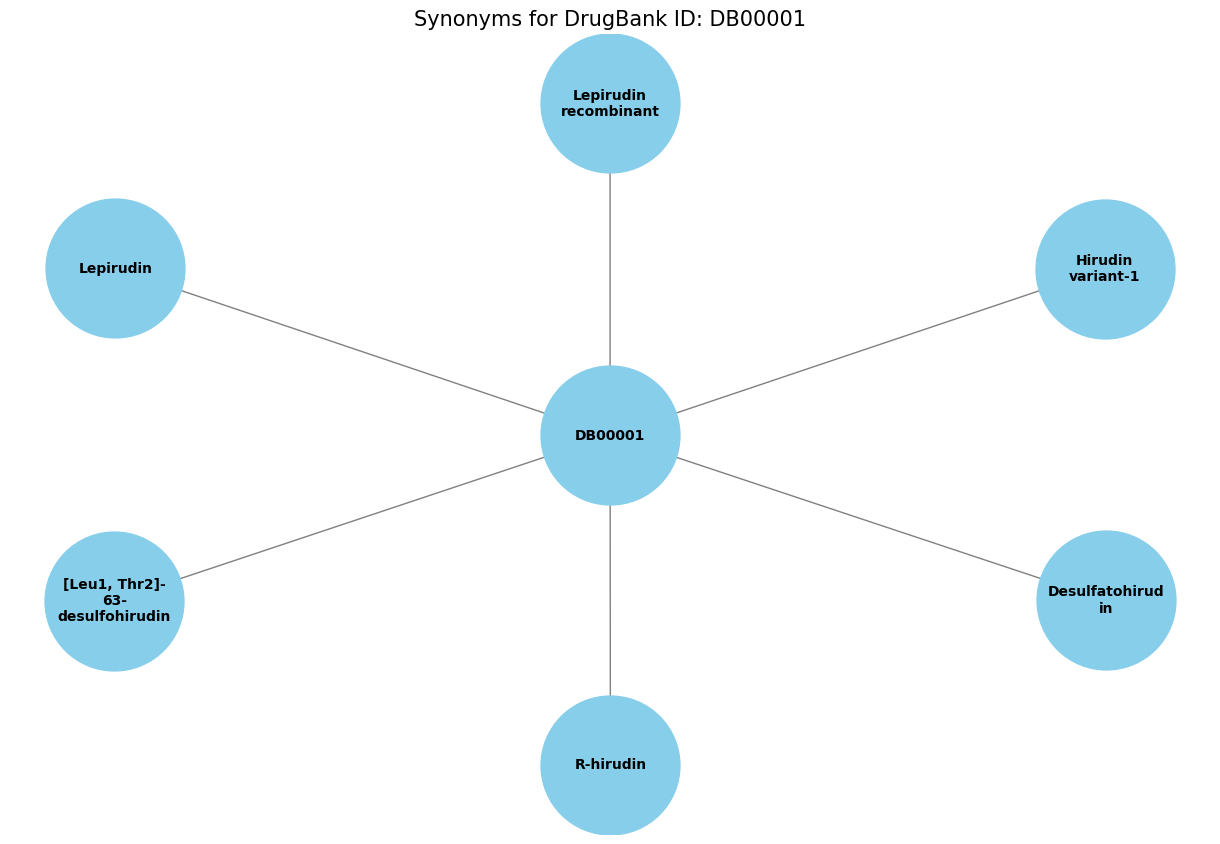

In [4]:
draw_synonyms_graph('DB00001')